# Claim 1: Input content contributes causally to ICL accuracy

Paired-design experiment over n prompts. Every prompt is evaluated under every condition, enabling prompt-level paired comparisons.

**Conditions (from least to most ablated):**
- `orig` — no change
- `shuffled` — inputs permuted within the prompt
- `wrong_task_inputs` — inputs drawn from one specific other task's input pool
- `random_from_input_pool` — inputs drawn from the union of all tasks' input pools
- `mean_embed` — input embeddings replaced by the mean embedding across all task inputs
- `star` — inputs replaced with `*`

**Pairwise comparisons plotted with CIs (each isolates one dimension):**
- `orig − shuffled` → pairing contribution
- `shuffled − wrong_task_inputs` → this-task category fit
- `wrong_task_inputs − random_from_input_pool` → single-task coherence
- `random_from_input_pool − mean_embed` → positional variability
- `mean_embed − star` → in-embedding-space-ness

In [1]:
import sys; sys.path.insert(0, '../..')
import torch, numpy as np, matplotlib.pyplot as plt, pickle, random, seaborn as sns
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from math import sqrt
from transformer_lens import HookedTransformer
from configs import *
from utils import *
%matplotlib inline

sns.set_context('notebook')

model = HookedTransformer.from_pretrained(MODEL_NAME, device='cuda', dtype=torch.float16)
model.eval()

with open('../../configs/splits.pkl', 'rb') as f:
    all_splits = pickle.load(f)

rng = random.Random(42)

N_PROMPTS_PER_TASK = 50

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-14 13:57:06.364060: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.96it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer


## Build the input pools and donor task mapping

In [2]:
W_E = model.W_E.detach()

input_pool_all = []
input_pool_all_tokids = []
for task_name, splits in all_splits.items():
    for pdata in splits['icl_prompts']:
        for inp, _ in pdata['demo_pairs']:
            input_pool_all.append(inp)
            toks = model.to_tokens(' ' + inp, prepend_bos=False)[0]
            input_pool_all_tokids.append(toks[0].item())

mean_input_embed = W_E[input_pool_all_tokids].mean(dim=0)

task_list = sorted(all_splits.keys())
donor_task = {}
for i, t in enumerate(task_list):
    donor_task[t] = task_list[(i + len(task_list) // 2) % len(task_list)]

print('Task → donor mapping:')
for t, d in donor_task.items():
    print(f'  {t:<40} ← {d}')

Task → donor mapping:
  knowledge/country_capital                ← linguistic/present_simple_gerund
  knowledge/football_player_position       ← linguistic/present_simple_past_perfect
  knowledge/location_continent             ← linguistic/present_simple_past_simple
  knowledge/location_country               ← linguistic/singular_plural
  knowledge/location_language              ← translation/en_es
  knowledge/location_religion              ← translation/en_fr
  knowledge/person_language                ← translation/en_it
  knowledge/person_profession              ← translation/es_en
  linguistic/antonyms                      ← translation/fr_en
  linguistic/plural_singular               ← translation/it_en
  linguistic/present_simple_gerund         ← knowledge/country_capital
  linguistic/present_simple_past_perfect   ← knowledge/football_player_position
  linguistic/present_simple_past_simple    ← knowledge/location_continent
  linguistic/singular_plural               ← knowledge/loc

## Collect all conditions (prompt-level matched)

In [3]:
CONDS = ['orig', 'shuffled', 'wrong_task_inputs', 'random_from_input_pool', 'mean_embed', 'star', 'query_only']
correct = {c: [] for c in CONDS}
prompt_task = []

def make_embed_hook(positions, replacement_vec):
    def hook_fn(emb, hook):
        for p in positions:
            emb[:, p, :] = replacement_vec.to(emb.dtype)
        return emb
    return hook_fn

for task_name, splits in tqdm(list(all_splits.items())):
    donor_prompts = all_splits[donor_task[task_name]]['icl_prompts']
    
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS_PER_TASK]):
        demos = pdata['demo_pairs']
        qi = pdata['query_input']
        ans = pdata.get('query_output')
        if ans is None: continue
        
        outputs = [o for _, o in demos]
        inputs  = [i for i, _ in demos]
        
        inputs_shuffled = inputs.copy(); rng.shuffle(inputs_shuffled)
        
        # 1-to-1 donor lookup: use the donor task's prompt at the same index p_idx,
        # and copy its demo inputs directly in their original order.
        donor_pdata = donor_prompts[p_idx % len(donor_prompts)]
        inputs_wrong = [i for i, _ in donor_pdata['demo_pairs']]
        # If donor has fewer demos than current, truncate/pad is unlikely but guard:
        if len(inputs_wrong) < len(demos):
            inputs_wrong = (inputs_wrong * ((len(demos) // len(inputs_wrong)) + 1))[:len(demos)]
        inputs_wrong = inputs_wrong[:len(demos)]
        
        inputs_random = [rng.choice(input_pool_all) for _ in range(len(demos))]
        
        prompts = {
            'orig':       pdata['prompt'],
            'query_only': f"{pdata['query_input']} \u2192",
            'shuffled': build_icl_prompt(list(zip(inputs_shuffled, outputs)), qi),
            'wrong_task_inputs':      build_icl_prompt(list(zip(inputs_wrong, outputs)), qi),
            'random_from_input_pool': build_icl_prompt(list(zip(inputs_random, outputs)), qi),
            'star':     build_icl_prompt([('*', o) for o in outputs], qi),
        }
        tokens = {k: model.to_tokens(v, prepend_bos=True) for k, v in prompts.items()}
        lasts  = {k: v.shape[1]-1 for k, v in tokens.items()}
        
        for k in ['orig', 'shuffled', 'wrong_task_inputs', 'random_from_input_pool', 'star', 'query_only']:
            with torch.no_grad():
                logits = model(tokens[k])[0, lasts[k]]
            correct[k].append(int(check_correct(model, logits, ans)))
        
        per_demo_orig = find_per_demo_positions(model, prompts['orig'], demos)
        input_positions = [p for d in per_demo_orig for p in d.get('input_positions', [])]
        hook = [('hook_embed', make_embed_hook(input_positions, mean_input_embed))]
        with torch.no_grad(), model.hooks(fwd_hooks=hook):
            logits = model(tokens['orig'])[0, lasts['orig']]
        correct['mean_embed'].append(int(check_correct(model, logits, ans)))
        
        prompt_task.append(task_name)
        torch.cuda.empty_cache()

for c in CONDS:
    correct[c] = np.array(correct[c])
prompt_task = np.array(prompt_task)
total_n = len(prompt_task)
print(f'\nTotal prompts scored: {total_n}')

100%|██████████| 20/20 [04:37<00:00, 13.90s/it]


Total prompts scored: 1000


## Marginal accuracies + aggregate plot

/tmp/ipykernel_2932919/1950849434.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_long, x='Condition', y='Correct', order=order_labels,


Condition                     Mean            [95% CI]
------------------------------------------------------
orig                         0.838  [0.814, 0.860]
shuffled                     0.316  [0.288, 0.345]
wrong_task_inputs            0.330  [0.302, 0.360]
random_from_input_pool       0.210  [0.186, 0.236]
mean_embed                   0.242  [0.216, 0.270]
star                         0.294  [0.267, 0.323]
query_only                   0.024  [0.016, 0.035]


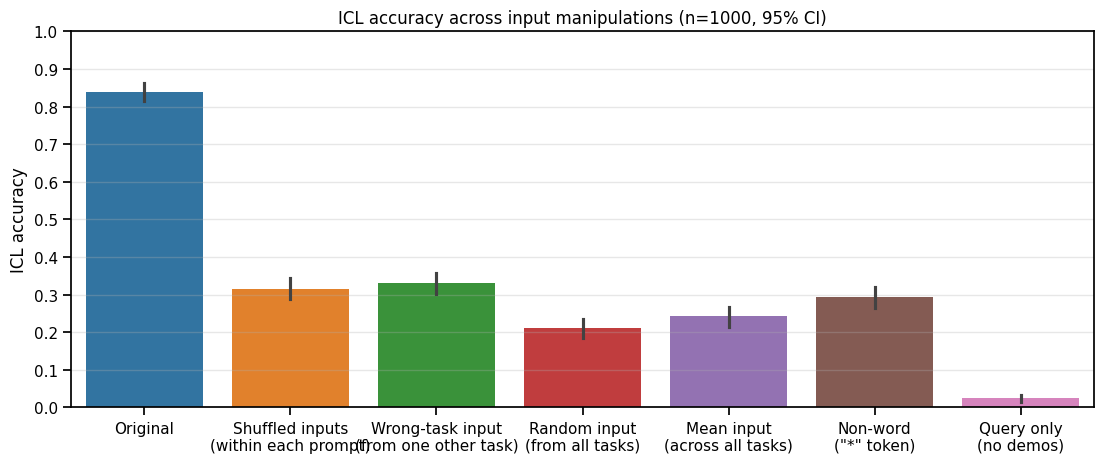

In [4]:
def wilson(k, n, Z=1.96):
    if n == 0: return 0, 0, 0
    p = k / n
    denom = 1 + Z**2/n
    c = (p + Z**2/(2*n)) / denom
    h = Z * sqrt(p*(1-p)/n + Z**2/(4*n**2)) / denom
    return p, max(0, c-h), min(1, c+h)

results = {c: wilson(correct[c].sum(), total_n) for c in CONDS}
print(f'{"Condition":<26} {"Mean":>7}  {"[95% CI]":>18}')
print('-' * 54)
for c in CONDS:
    p, lo, hi = results[c]
    print(f'{c:<26} {p:>7.3f}  [{lo:.3f}, {hi:.3f}]')

tick_map = {
    'orig': 'Original',
    'shuffled': 'Shuffled inputs\n(within each prompt)',
    'wrong_task_inputs': 'Wrong-task input\n(from one other task)',
    'random_from_input_pool': 'Random input\n(from all tasks)',
    'mean_embed': 'Mean input\n(across all tasks)',
    'star': 'Non-word\n("*" token)',
    'query_only': 'Query only\n(no demos)',
}
order_keys = CONDS
order_labels = [tick_map[k] for k in order_keys]

df_long = pd.DataFrame({
    'Condition': np.concatenate([[tick_map[c]] * total_n for c in order_keys]),
    'Correct':   np.concatenate([correct[c] for c in order_keys]),
})

fig, ax = plt.subplots(figsize=(6.4*1.75, 4.8))
sns.barplot(data=df_long, x='Condition', y='Correct', order=order_labels,
            palette='tab10', errorbar=('ci', 95),
            edgecolor='black', linewidth=0, ax=ax)
ax.set_ylabel('ICL accuracy')
ax.set_xlabel('')
ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_title(f'ICL accuracy across input manipulations (n={total_n}, 95% CI)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

/tmp/ipykernel_2932919/902803829.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_t, x='Condition', y='Correct', order=order_labels,
/tmp/ipykernel_2932919/902803829.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_t, x='Condition', y='Correct', order=order_labels,
/tmp/ipykernel_2932919/902803829.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_t, x='Condition', y='Correct', order=order_labels,
/tmp/ipykernel_2932919/902803829.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated

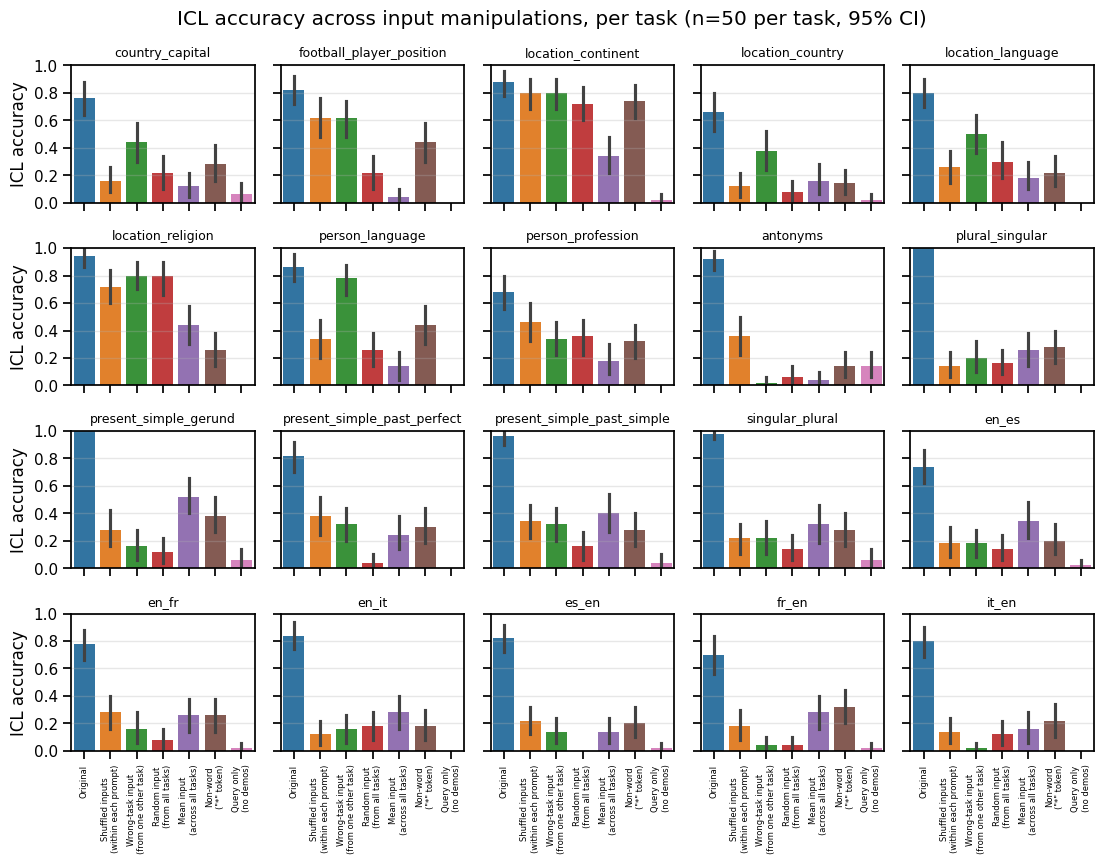

In [5]:
task_list = sorted(set(prompt_task))
n_cols = 5
n_rows = int(np.ceil(len(task_list) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.4*1.75, 2.2*n_rows),
                         sharey=True, sharex=True)
axes = axes.flatten()

for ax, t in zip(axes, task_list):
    mask = prompt_task == t
    df_t = pd.DataFrame({
        'Condition': np.concatenate([[tick_map[c]] * mask.sum() for c in order_keys]),
        'Correct':   np.concatenate([correct[c][mask] for c in order_keys]),
    })
    sns.barplot(data=df_t, x='Condition', y='Correct', order=order_labels,
                palette='tab10', errorbar=('ci', 95),
                edgecolor='black', linewidth=0, ax=ax)
    ax.set_title(t.split('/')[-1], fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('ICL accuracy' if ax in axes[::n_cols] else '')
    ax.set_ylim(0, 1.0)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.tick_params(axis='x', labelrotation=90, labelsize=6)
    ax.grid(True, alpha=0.3, axis='y')

for ax in axes[len(task_list):]:
    ax.set_visible(False)

fig.suptitle(f'ICL accuracy across input manipulations, per task (n={mask.sum()} per task, 95% CI)')
plt.tight_layout()
plt.show()

## Pairwise prompt-level differences (bootstrap CIs)

In [6]:
COMPARISONS = [
    ('orig', 'shuffled',                                    'Original vs.\nShuffled'),
    ('shuffled', 'wrong_task_inputs',                       'Shuffled vs.\nWrong-task input'),
    ('wrong_task_inputs', 'random_from_input_pool',         'Wrong-task input vs.\nRandom input'),
    ('random_from_input_pool', 'mean_embed',                'Random input vs.\nMean input'),
    ('mean_embed', 'star',                                  'Mean input vs.\nNon-word'),
]

N_BOOT = 5000
boot_rng = np.random.default_rng(42)

def bootstrap_diff_ci(a, b, n_boot=N_BOOT, ci=0.95):
    d = a - b
    n = len(d)
    means = np.empty(n_boot)
    for i in range(n_boot):
        idx = boot_rng.integers(0, n, n)
        means[i] = d[idx].mean()
    lo = np.percentile(means, 100 * (1 - ci) / 2)
    hi = np.percentile(means, 100 * (1 + ci) / 2)
    return d.mean(), lo, hi

diff_results = []
print(f'{"Comparison":<50} {"Δ mean":>8} {"[95% bootstrap CI]":>24}')
print('-' * 86)
for a, b, label in COMPARISONS:
    m, lo, hi = bootstrap_diff_ci(correct[a], correct[b])
    diff_results.append((a, b, label, m, lo, hi))
    print(f'{a} − {b:<30} {m:>+8.3f}   [{lo:+.3f}, {hi:+.3f}]')

Comparison                                           Δ mean       [95% bootstrap CI]
--------------------------------------------------------------------------------------
orig − shuffled                         +0.522   [+0.488, +0.554]
shuffled − wrong_task_inputs                -0.014   [-0.046, +0.018]
wrong_task_inputs − random_from_input_pool           +0.120   [+0.091, +0.148]
random_from_input_pool − mean_embed                       -0.032   [-0.066, +0.002]
mean_embed − star                             -0.052   [-0.088, -0.016]


## Pairwise differences plot

/tmp/ipykernel_2932919/213831846.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diff_df, y='Comparison', x='Mean', order=diff_df['Comparison'],


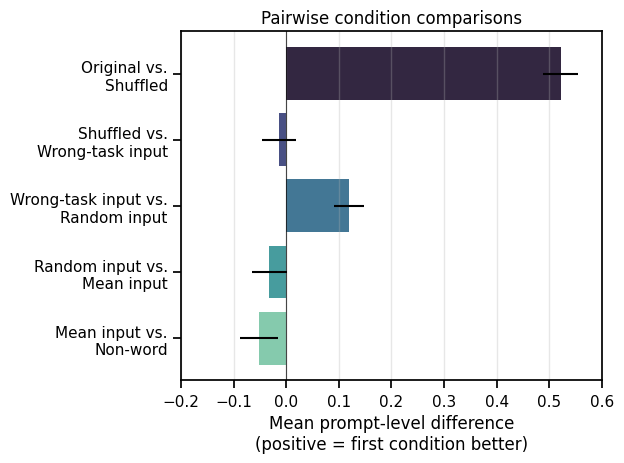

In [7]:
diff_df = pd.DataFrame({
    'Comparison': [r[2] for r in diff_results],
    'Mean':       [r[3] for r in diff_results],
    'Lo':         [r[4] for r in diff_results],
    'Hi':         [r[5] for r in diff_results],
})
diff_df['err_lo'] = diff_df['Mean'] - diff_df['Lo']
diff_df['err_hi'] = diff_df['Hi']   - diff_df['Mean']

fig, ax = plt.subplots(figsize=(6.4, 4.8))
palette = sns.color_palette('mako', n_colors=len(diff_df))
sns.barplot(data=diff_df, y='Comparison', x='Mean', order=diff_df['Comparison'],
            palette=palette, edgecolor='black', linewidth=0, ax=ax)
ax.errorbar(x=diff_df['Mean'], y=np.arange(len(diff_df)),
            xerr=[diff_df['err_lo'], diff_df['err_hi']],
            fmt='none', color='black')
ax.axvline(0, color='black', lw=0.8, alpha=0.7)
ax.set_xlabel('Mean prompt-level difference\n(positive = first condition better)')
ax.set_ylabel('')
ax.set_xticks(np.arange(-0.2, 0.7, 0.1))
ax.set_title(f'Pairwise condition comparisons')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

## Task-level heterogeneity

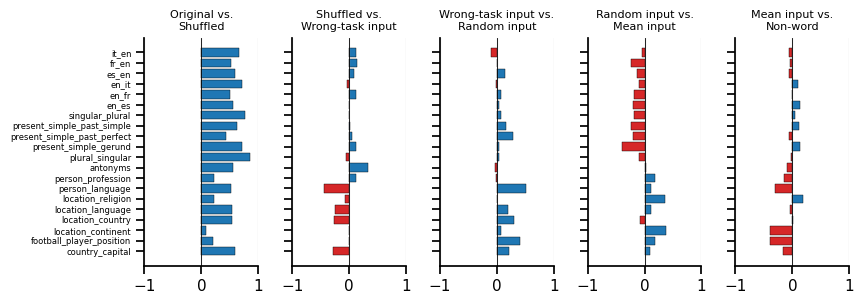

In [ ]:
task_list_sorted = sorted(set(prompt_task))
short_task = [t.split('/')[-1] for t in task_list_sorted]

rows = []
for t, short in zip(task_list_sorted, short_task):
    mask = prompt_task == t
    for a, b, label in COMPARISONS:
        rows.append({'task': short, 'comparison': label,
                     'diff': (correct[a][mask] - correct[b][mask]).mean()})
het_df = pd.DataFrame(rows)

g = sns.FacetGrid(het_df, col='comparison', col_wrap=len(COMPARISONS),
                  height=3.2, aspect=0.55, sharey=True)
def _bar(data, **kw):
    ax = plt.gca()
    colors = ['tab:blue' if d >= 0 else 'tab:red' for d in data['diff']]
    ax.barh(np.arange(len(data)), data['diff'], color=colors, edgecolor='black', linewidth=0.3)
    ax.axvline(0, color='black', lw=0.6)
    ax.set_xlim(-1, 1) 
    ax.set_yticks(np.arange(len(data)))
    ax.set_yticklabels(data['task'], fontsize=6)
    ax.grid(True, alpha=0.3, axis='x')

g.map_dataframe(_bar)
g.set_titles(col_template='{col_name}', size=8)
g.set_axis_labels('', '')
plt.tight_layout(); plt.show()

## Partial shuffling: vary the number of demos with correct pairings

For each prompt, keep k of the 10 demos paired correctly (randomly chosen which k) and shuffle the remaining 10−k demos among themselves. 
At k=0 this equals `shuffled`; at k=10 it equals `orig`. Intermediate values tell you whether the model needs many correctly-paired demos, just a few, or at least some threshold to form a working task vector.

In [16]:
K_VALUES = list(range(0, 11))

def positions_for_scheme(scheme, k, n_demos):
    if k == 0: return set()
    if k == n_demos: return set(range(n_demos))
    if scheme == 'random':
        return set(rng.sample(range(n_demos), k))
    if scheme == 'first':
        return set(range(k))
    if scheme == 'last':
        return set(range(n_demos - k, n_demos))
    if scheme == 'evenly_spaced':
        # k evenly spaced positions in [0, n_demos-1]
        return set(np.round(np.linspace(0, n_demos - 1, k)).astype(int).tolist())
    raise ValueError(scheme)

SCHEMES = ['random', 'first', 'last', 'evenly_spaced']
correct_input_pos = {s: {k: [] for k in K_VALUES} for s in SCHEMES}
prompt_task_pos = []

for task_name, splits in tqdm(list(all_splits.items())):
    for pdata in splits['icl_prompts'][:N_PROMPTS_PER_TASK]:
        demos = pdata['demo_pairs']
        qi = pdata['query_input']
        ans = pdata.get('query_output')
        if ans is None: continue
        
        inputs  = [i for i, _ in demos]
        outputs = [o for _, o in demos]
        n_demos = len(demos)
        
        for scheme in SCHEMES:
            for k in K_VALUES:
                intact = positions_for_scheme(scheme, k, n_demos)
                shuffle_idx = [i for i in range(n_demos) if i not in intact]
                shuffled_inputs = [inputs[i] for i in shuffle_idx]
                rng.shuffle(shuffled_inputs)
                new_inputs = inputs.copy()
                for pos, orig_idx in enumerate(shuffle_idx):
                    new_inputs[orig_idx] = shuffled_inputs[pos]
                
                prompt = build_icl_prompt(list(zip(new_inputs, outputs)), qi)
                tokens = model.to_tokens(prompt, prepend_bos=True)
                last = tokens.shape[1] - 1
                with torch.no_grad():
                    logits = model(tokens)[0, last]
                correct_input_pos[scheme][k].append(int(check_correct(model, logits, ans)))
        
        prompt_task_pos.append(task_name)
        torch.cuda.empty_cache()

for s in SCHEMES:
    for k in K_VALUES:
        correct_input_pos[s][k] = np.array(correct_input_pos[s][k])
prompt_task_pos = np.array(prompt_task_pos)
n_pos = len(prompt_task_pos)
print(f'\nTotal prompts: {n_pos}')

100%|██████████| 20/20 [28:24<00:00, 85.24s/it]


Total prompts: 1000


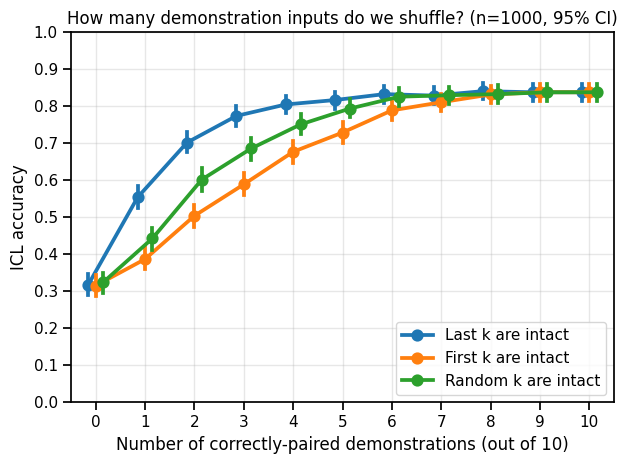

In [17]:
rows = []
for s in SCHEMES[:-1][::-1]:
    for k in K_VALUES:
        for v in correct_input_pos[s][k]:
            rows.append({'Scheme': s, 'k': k, 'Correct': v})
df_input_pos = pd.DataFrame(rows)

scheme_labels = {
    'random': 'Random k are intact',
    'first':  'First k are intact',
    'last':   'Last k are intact',
}
df_input_pos['Scheme'] = df_input_pos['Scheme'].map(scheme_labels)
label_order = [scheme_labels[s] for s in SCHEMES[:-1][::-1]]

fig, ax = plt.subplots(figsize=(6.4, 4.8))
sns.pointplot(data=df_input_pos, x='k', y='Correct', hue='Scheme', hue_order=label_order,
              errorbar=('ci', 95), ax=ax, dodge=0.3)
ax.set_xlabel('Number of correctly-paired demonstrations (out of 10)')
ax.set_ylabel('ICL accuracy')
ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_title(f'How many demonstration inputs do we shuffle? (n={n_pos}, 95% CI)')
ax.grid(True, alpha=0.3)
ax.legend(title='', loc='lower right')
plt.tight_layout(); plt.show()

/tmp/ipykernel_2932919/1835112966.py:25: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=sub, x='k', y='Correct', hue='Scheme', hue_order=label_order, scale=0.5,
/tmp/ipykernel_2932919/1835112966.py:25: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=sub, x='k', y='Correct', hue='Scheme', hue_order=label_order, scale=0.5,
/tmp/ipykernel_2932919/1835112966.py:25: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=sub, x='k', y='Correct', hue='Sc

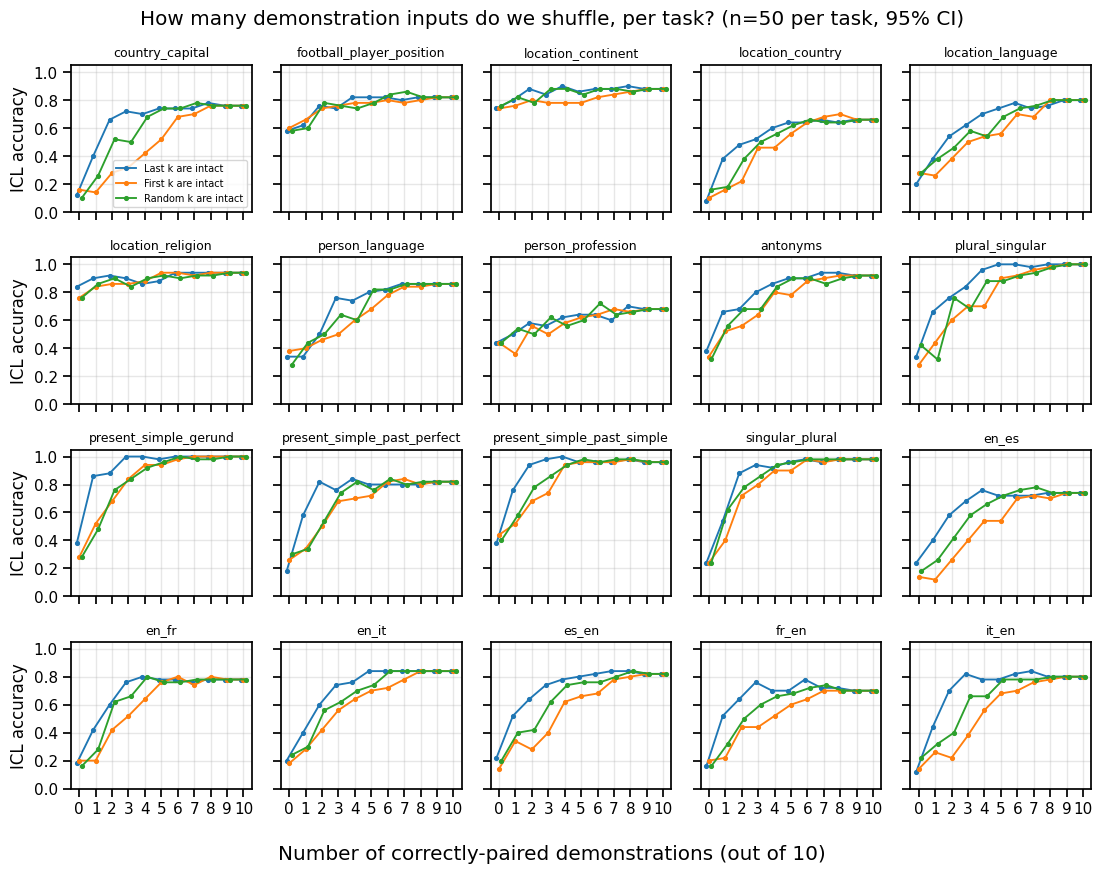

In [18]:
task_list = sorted(set(prompt_task_pos))
n_cols = 5
n_rows = int(np.ceil(len(task_list) / n_cols))

scheme_labels = {
    'random': 'Random k are intact',
    'first':  'First k are intact',
    'last':   'Last k are intact',
}

rows = []
for s in SCHEMES[:-1][::-1]:
    for k in K_VALUES:
        for v, t in zip(correct_input_pos[s][k], prompt_task_pos):
            rows.append({'Scheme': scheme_labels[s], 'k': k, 'task': t, 'Correct': v})
df_input_pos_task = pd.DataFrame(rows)
label_order = [scheme_labels[s] for s in SCHEMES[:-1][::-1]]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.4*1.75, 2.2*n_rows),
                         sharey=True, sharex=True)
axes = axes.flatten()

for ax, t in zip(axes, task_list):
    sub = df_input_pos_task[df_input_pos_task['task'] == t]
    sns.pointplot(data=sub, x='k', y='Correct', hue='Scheme', hue_order=label_order, scale=0.5,
                  errorbar=None, ax=ax, dodge=0.3, legend=(ax is axes[0]))
    ax.set_title(t.split('/')[-1], fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('ICL accuracy' if ax in axes[::n_cols] else '')
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.grid(True, alpha=0.3)

axes[0].legend(title='', loc='lower right', fontsize=7)

for ax in axes[len(task_list):]:
    ax.set_visible(False)

fig.supxlabel('Number of correctly-paired demonstrations (out of 10)')
fig.suptitle(f'How many demonstration inputs do we shuffle, per task? (n={n_pos // len(task_list)} per task, 95% CI)')
plt.tight_layout()
plt.show()

# Output-side analyses

Mirroring the input-side analyses above, but manipulating the **outputs** of the demonstrations instead of the inputs. Each input-side manipulation has a conceptually symmetric output-side analog:

- `shuffled_outputs` — output words permuted within the prompt. Breaks correct pairings symmetric to input-side shuffled; preserves the correct task's output vocabulary.
- `wrong_task_outputs` — outputs replaced verbatim with outputs from one specific other task's prompt (1-to-1 by prompt index). Single-task-coherent but from the wrong task.
- `random_from_output_pool` — outputs replaced with random draws from the union of all tasks' outputs. Breaks task-coherent output vocabulary.
- `mean_embed_outputs` — output-position embeddings overwritten with the mean output embedding across all tasks. Breaks lexicality at the representation level (token IDs preserved).
- `star_outputs` — each output replaced with `*`. Breaks lexicality at the token level. **Caveat:** the model may pattern-match to predict `*` regardless of the task vector — worth watching for.

The final query's output is never manipulated — only the demo outputs.

## Build output pool

In [10]:
output_pool_all = []
output_pool_all_tokids = []
for task_name, splits in all_splits.items():
    for pdata in splits['icl_prompts']:
        for _, out in pdata['demo_pairs']:
            output_pool_all.append(out)
            toks = model.to_tokens(' ' + out, prepend_bos=False)[0]
            output_pool_all_tokids.append(toks[0].item())

mean_output_embed = W_E[output_pool_all_tokids].mean(dim=0)
print(f'Output pool: {len(output_pool_all)} tokens total, {len(set(output_pool_all))} unique')

Output pool: 10000 tokens total, 3075 unique


## Collect output-side conditions

In [11]:
CONDS_OUT = ['orig_out', 'shuffled_outputs', 'wrong_task_outputs',
             'random_from_output_pool', 'mean_embed_outputs', 'star_outputs', 'query_only']
correct_out = {c: [] for c in CONDS_OUT}
prompt_task_out = []

for task_name, splits in tqdm(list(all_splits.items())):
    donor_prompts = all_splits[donor_task[task_name]]['icl_prompts']
    
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS_PER_TASK]):
        demos = pdata['demo_pairs']
        qi = pdata['query_input']
        ans = pdata.get('query_output')
        if ans is None: continue
        
        inputs  = [i for i, _ in demos]
        outputs = [o for _, o in demos]
        
        outputs_shuffled = outputs.copy(); rng.shuffle(outputs_shuffled)
        
        donor_pdata = donor_prompts[p_idx % len(donor_prompts)]
        outputs_wrong = [o for _, o in donor_pdata['demo_pairs']]
        if len(outputs_wrong) < len(demos):
            outputs_wrong = (outputs_wrong * ((len(demos) // len(outputs_wrong)) + 1))[:len(demos)]
        outputs_wrong = outputs_wrong[:len(demos)]
        
        outputs_random = [rng.choice(output_pool_all) for _ in range(len(demos))]
        
        prompts = {
            'orig_out':   pdata['prompt'],
            'query_only': f"{pdata['query_input']} \u2192",
            'shuffled_outputs':        build_icl_prompt(list(zip(inputs, outputs_shuffled)), qi),
            'wrong_task_outputs':      build_icl_prompt(list(zip(inputs, outputs_wrong)),    qi),
            'random_from_output_pool': build_icl_prompt(list(zip(inputs, outputs_random)),   qi),
            'star_outputs':            build_icl_prompt([(i, '*') for i in inputs], qi),
        }
        tokens = {k: model.to_tokens(v, prepend_bos=True) for k, v in prompts.items()}
        lasts  = {k: v.shape[1]-1 for k, v in tokens.items()}
        
        for k in ['orig_out', 'shuffled_outputs', 'wrong_task_outputs',
                  'random_from_output_pool', 'star_outputs', 'query_only']:
            with torch.no_grad():
                logits = model(tokens[k])[0, lasts[k]]
            correct_out[k].append(int(check_correct(model, logits, ans)))
        
        # mean_embed_outputs: hook hook_embed, overwrite output positions only
        per_demo_orig = find_per_demo_positions(model, prompts['orig_out'], demos)
        output_positions = [p for d in per_demo_orig for p in d.get('output_positions', [])]
        hook = [('hook_embed', make_embed_hook(output_positions, mean_output_embed))]
        with torch.no_grad(), model.hooks(fwd_hooks=hook):
            logits = model(tokens['orig_out'])[0, lasts['orig_out']]
        correct_out['mean_embed_outputs'].append(int(check_correct(model, logits, ans)))
        
        prompt_task_out.append(task_name)
        torch.cuda.empty_cache()

for c in CONDS_OUT:
    correct_out[c] = np.array(correct_out[c])
prompt_task_out = np.array(prompt_task_out)
total_n_out = len(prompt_task_out)
print(f'\nTotal prompts scored: {total_n_out}')

100%|██████████| 20/20 [04:39<00:00, 14.00s/it]


Total prompts scored: 1000


## Marginal accuracies + aggregate plot (output side)

/tmp/ipykernel_2932919/1641788277.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_long_out, x='Condition', y='Correct', order=order_labels_out,


Condition                       Mean            [95% CI]
--------------------------------------------------------
orig_out                       0.838  [0.814, 0.860]
shuffled_outputs               0.312  [0.284, 0.341]
wrong_task_outputs             0.011  [0.006, 0.020]
random_from_output_pool        0.038  [0.028, 0.052]
mean_embed_outputs             0.123  [0.104, 0.145]
star_outputs                   0.000  [0.000, 0.004]
query_only                     0.024  [0.016, 0.035]


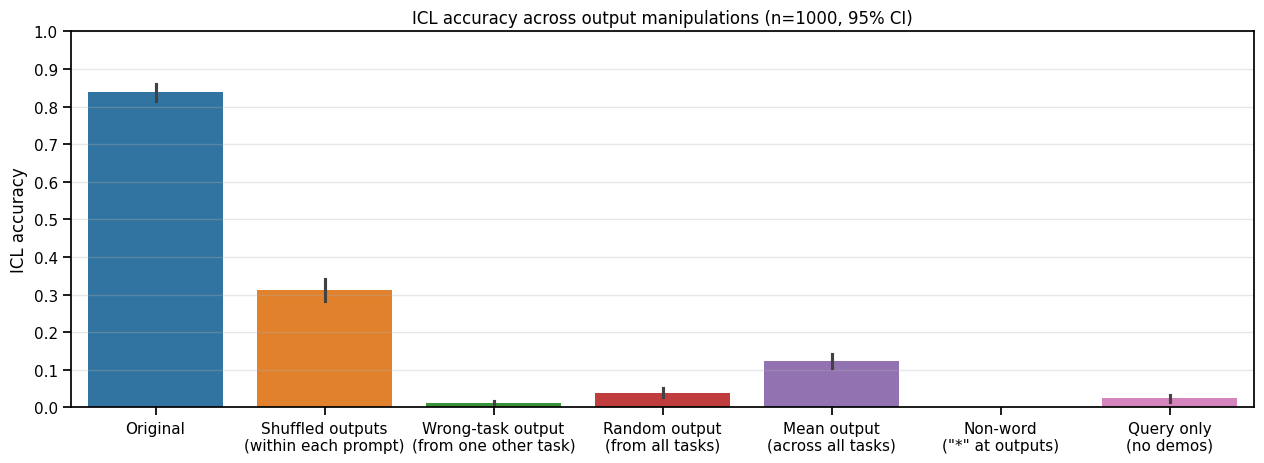

In [12]:
results_out = {c: wilson(correct_out[c].sum(), total_n_out) for c in CONDS_OUT}
print(f'{"Condition":<28} {"Mean":>7}  {"[95% CI]":>18}')
print('-' * 56)
for c in CONDS_OUT:
    p, lo, hi = results_out[c]
    print(f'{c:<28} {p:>7.3f}  [{lo:.3f}, {hi:.3f}]')

tick_map_out = {
    'orig_out': 'Original',
    'shuffled_outputs': 'Shuffled outputs\n(within each prompt)',
    'wrong_task_outputs': 'Wrong-task output\n(from one other task)',
    'random_from_output_pool': 'Random output\n(from all tasks)',
    'mean_embed_outputs': 'Mean output\n(across all tasks)',
    'star_outputs': 'Non-word\n("*" at outputs)',
    'query_only': 'Query only\n(no demos)',
}
order_keys_out = CONDS_OUT
order_labels_out = [tick_map_out[k] for k in order_keys_out]

df_long_out = pd.DataFrame({
    'Condition': np.concatenate([[tick_map_out[c]] * total_n_out for c in order_keys_out]),
    'Correct':   np.concatenate([correct_out[c] for c in order_keys_out]),
})

fig, ax = plt.subplots(figsize=(6.4*2, 4.8))
sns.barplot(data=df_long_out, x='Condition', y='Correct', order=order_labels_out,
            palette='tab10', errorbar=('ci', 95),
            edgecolor='black', linewidth=0, ax=ax)
ax.set_ylabel('ICL accuracy')
ax.set_xlabel('')
ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_title(f'ICL accuracy across output manipulations (n={total_n_out}, 95% CI)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## Per-task breakdown (output side)

/tmp/ipykernel_2932919/4114325077.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_t, x='Condition', y='Correct', order=order_labels_out,
/tmp/ipykernel_2932919/4114325077.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_t, x='Condition', y='Correct', order=order_labels_out,
/tmp/ipykernel_2932919/4114325077.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_t, x='Condition', y='Correct', order=order_labels_out,
/tmp/ipykernel_2932919/4114325077.py:15: FutureWarning: 

Passing `palette` without assigning `hu

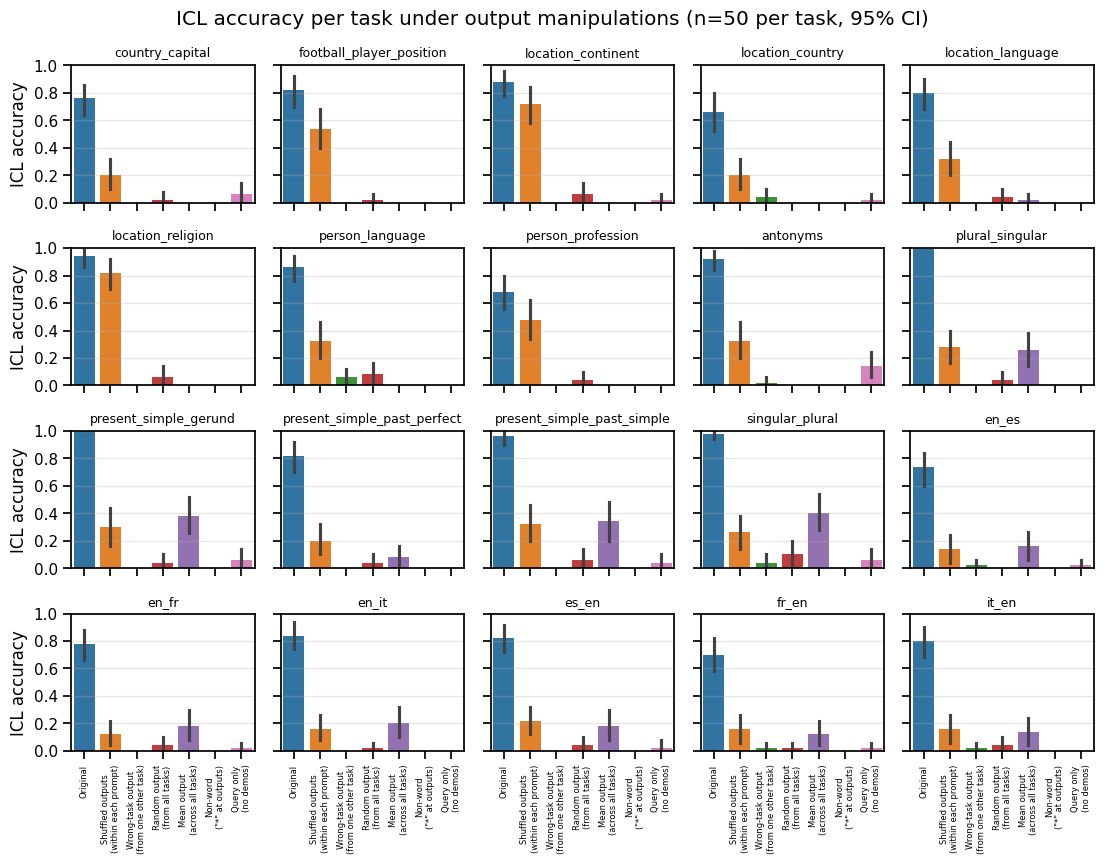

In [13]:
task_list_out = sorted(set(prompt_task_out))
n_cols = 5
n_rows = int(np.ceil(len(task_list_out) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.4*1.75, 2.2*n_rows),
                         sharey=True, sharex=True)
axes = axes.flatten()

for ax, t in zip(axes, task_list_out):
    mask = prompt_task_out == t
    df_t = pd.DataFrame({
        'Condition': np.concatenate([[tick_map_out[c]] * mask.sum() for c in order_keys_out]),
        'Correct':   np.concatenate([correct_out[c][mask] for c in order_keys_out]),
    })
    sns.barplot(data=df_t, x='Condition', y='Correct', order=order_labels_out,
                palette='tab10', errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_title(t.split('/')[-1], fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('ICL accuracy' if ax in axes[::n_cols] else '')
    ax.set_ylim(0, 1.0)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.tick_params(axis='x', labelrotation=90, labelsize=6)
    ax.grid(True, alpha=0.3, axis='y')

for ax in axes[len(task_list_out):]:
    ax.set_visible(False)

fig.suptitle(f'ICL accuracy per task under output manipulations (n={mask.sum()} per task, 95% CI)')
plt.tight_layout(); plt.show()

## Pairwise prompt-level differences (output side)

Comparison                                                Δ mean       [95% bootstrap CI]
--------------------------------------------------------------------------------------------
orig_out − shuffled_outputs                      +0.526   [+0.494, +0.559]
shuffled_outputs − wrong_task_outputs                    +0.301   [+0.272, +0.330]
wrong_task_outputs − random_from_output_pool               -0.027   [-0.041, -0.014]
random_from_output_pool − mean_embed_outputs                    -0.085   [-0.108, -0.062]
mean_embed_outputs − star_outputs                          +0.123   [+0.103, +0.143]


/tmp/ipykernel_2932919/2099063376.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diff_df_out, y='Comparison', x='Mean', order=diff_df_out['Comparison'],


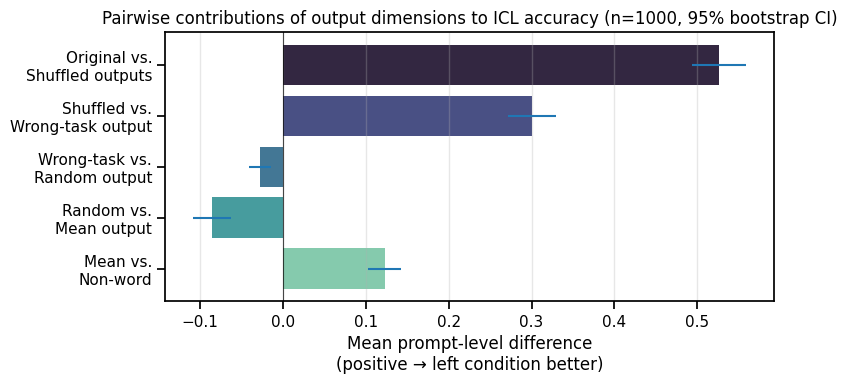

In [14]:
COMPARISONS_OUT = [
    ('orig_out', 'shuffled_outputs',                        'Original vs.\nShuffled outputs'),
    ('shuffled_outputs', 'wrong_task_outputs',              'Shuffled vs.\nWrong-task output'),
    ('wrong_task_outputs', 'random_from_output_pool',       'Wrong-task vs.\nRandom output'),
    ('random_from_output_pool', 'mean_embed_outputs',       'Random vs.\nMean output'),
    ('mean_embed_outputs', 'star_outputs',                  'Mean vs.\nNon-word'),
]

diff_results_out = []
print(f'{"Comparison":<55} {"Δ mean":>8} {"[95% bootstrap CI]":>24}')
print('-' * 92)
for a, b, label in COMPARISONS_OUT:
    m, lo, hi = bootstrap_diff_ci(correct_out[a], correct_out[b])
    diff_results_out.append((a, b, label, m, lo, hi))
    print(f'{a} − {b:<35} {m:>+8.3f}   [{lo:+.3f}, {hi:+.3f}]')

diff_df_out = pd.DataFrame({
    'Comparison': [r[2] for r in diff_results_out],
    'Mean':       [r[3] for r in diff_results_out],
    'err_lo':     [r[3] - r[4] for r in diff_results_out],
    'err_hi':     [r[5] - r[3] for r in diff_results_out],
})

fig, ax = plt.subplots(figsize=(6.4*1.25, 4.0))
palette = sns.color_palette('mako', n_colors=len(diff_df_out))
sns.barplot(data=diff_df_out, y='Comparison', x='Mean', order=diff_df_out['Comparison'],
            palette=palette, linewidth=0, ax=ax)
ax.errorbar(x=diff_df_out['Mean'], y=np.arange(len(diff_df_out)),
            xerr=[diff_df_out['err_lo'], diff_df_out['err_hi']], fmt='none')
ax.axvline(0, color='black', lw=0.8, alpha=0.7)
ax.set_xlabel('Mean prompt-level difference\n(positive → left condition better)')
ax.set_ylabel('')
ax.set_title(f'Pairwise contributions of output dimensions to ICL accuracy (n={total_n_out}, 95% bootstrap CI)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

## Partial shuffling of outputs: k-sweep with position scheme

Same structure as input-side partial shuffling but manipulating outputs instead. At k=10, all outputs stay correctly paired; at k=0, all outputs are shuffled among positions.

In [19]:
SCHEMES_OUT = ['random', 'first', 'last']
correct_output_pos = {s: {k: [] for k in K_VALUES} for s in SCHEMES_OUT}
prompt_task_out_pos = []

for task_name, splits in tqdm(list(all_splits.items())):
    for pdata in splits['icl_prompts'][:N_PROMPTS_PER_TASK]:
        demos = pdata['demo_pairs']
        qi = pdata['query_input']
        ans = pdata.get('query_output')
        if ans is None: continue
        
        inputs  = [i for i, _ in demos]
        outputs = [o for _, o in demos]
        n_demos = len(demos)
        
        for scheme in SCHEMES_OUT:
            for k in K_VALUES:
                intact = positions_for_scheme(scheme, k, n_demos)
                shuffle_idx = [i for i in range(n_demos) if i not in intact]
                shuffled_o = [outputs[i] for i in shuffle_idx]
                rng.shuffle(shuffled_o)
                new_outputs = outputs.copy()
                for pos, orig_idx in enumerate(shuffle_idx):
                    new_outputs[orig_idx] = shuffled_o[pos]
                
                prompt = build_icl_prompt(list(zip(inputs, new_outputs)), qi)
                tokens = model.to_tokens(prompt, prepend_bos=True)
                last = tokens.shape[1] - 1
                with torch.no_grad():
                    logits = model(tokens)[0, last]
                correct_output_pos[scheme][k].append(int(check_correct(model, logits, ans)))
        
        prompt_task_out_pos.append(task_name)
        torch.cuda.empty_cache()

for s in SCHEMES_OUT:
    for k in K_VALUES:
        correct_output_pos[s][k] = np.array(correct_output_pos[s][k])
prompt_task_out_pos = np.array(prompt_task_out_pos)
n_out_pos = len(prompt_task_out_pos)
print(f'\nTotal prompts: {n_out_pos}')

100%|██████████| 20/20 [21:23<00:00, 64.19s/it]


Total prompts: 1000


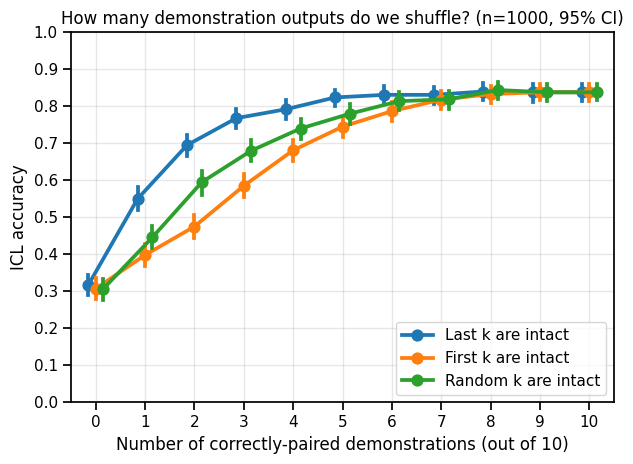

In [20]:
rows = []
scheme_labels_out = {
    'random': 'Random k are intact',
    'first':  'First k are intact',
    'last':   'Last k are intact',
}
for s in SCHEMES_OUT[::-1]:
    for k in K_VALUES:
        for v in correct_output_pos[s][k]:
            rows.append({'Scheme': scheme_labels_out[s], 'k': k, 'Correct': v})
df_output_pos = pd.DataFrame(rows)
label_order_out = [scheme_labels_out[s] for s in SCHEMES_OUT[::-1]]

fig, ax = plt.subplots(figsize=(6.4, 4.8))
sns.pointplot(data=df_output_pos, x='k', y='Correct', hue='Scheme', hue_order=label_order_out,
              errorbar=('ci', 95), ax=ax, dodge=0.3)
ax.set_xlabel('Number of correctly-paired demonstrations (out of 10)')
ax.set_ylabel('ICL accuracy')
ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_title(f'How many demonstration outputs do we shuffle? (n={n_out_pos}, 95% CI)')
ax.grid(True, alpha=0.3)
ax.legend(title='', loc='lower right')
plt.tight_layout(); plt.show()

### Per-task panel

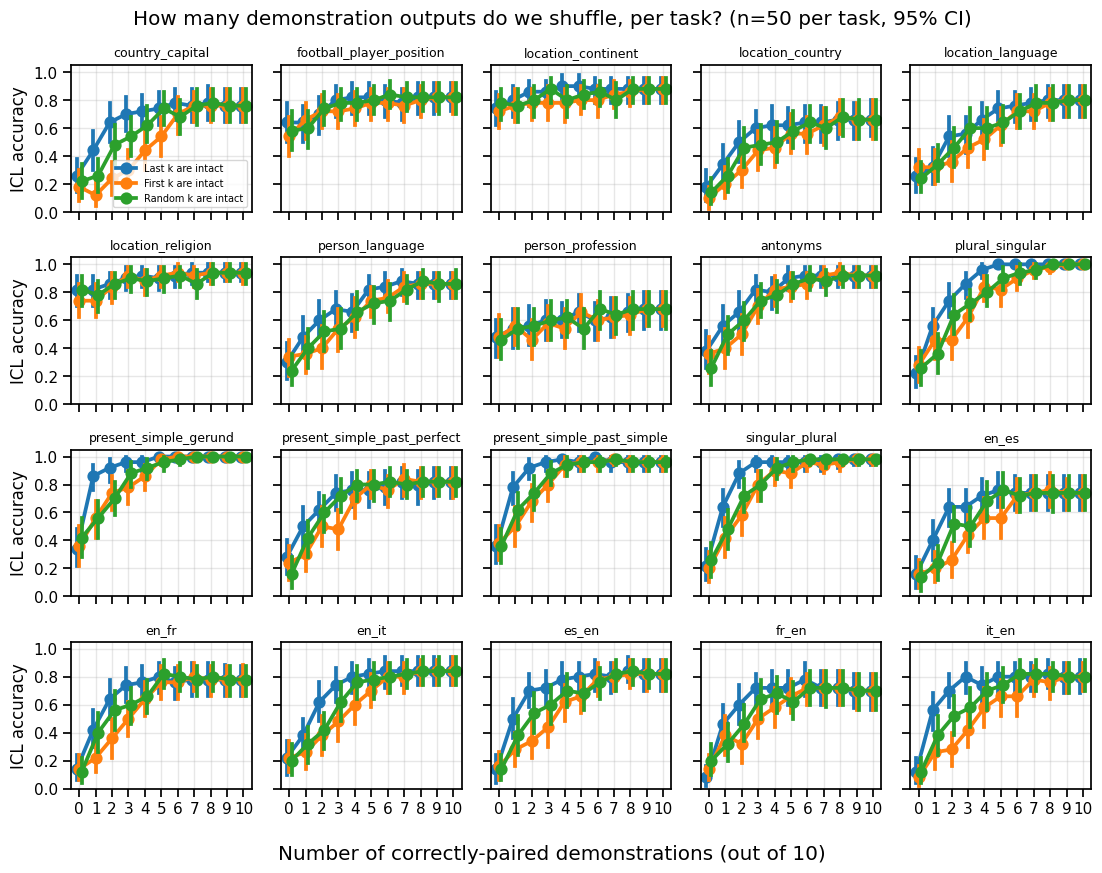

In [21]:
task_list = sorted(set(prompt_task_out_pos))
n_cols = 5
n_rows = int(np.ceil(len(task_list) / n_cols))

rows = []
for s in SCHEMES_OUT[::-1]:
    for k in K_VALUES:
        for v, t in zip(correct_output_pos[s][k], prompt_task_out_pos):
            rows.append({'Scheme': scheme_labels_out[s], 'k': k, 'task': t, 'Correct': v})
df_output_pos_task = pd.DataFrame(rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.4*1.75, 2.2*n_rows),
                         sharey=True, sharex=True)
axes = axes.flatten()

for ax, t in zip(axes, task_list):
    sub = df_output_pos_task[df_output_pos_task['task'] == t]
    sns.pointplot(data=sub, x='k', y='Correct', hue='Scheme', hue_order=label_order_out,
                  errorbar=('ci', 95), ax=ax, dodge=0.3, legend=(ax is axes[0]))
    ax.set_title(t.split('/')[-1], fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('ICL accuracy' if ax in axes[::n_cols] else '')
    ax.set_ylim(0, 1.05)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.grid(True, alpha=0.3)

axes[0].legend(title='', loc='lower right', fontsize=7)
for ax in axes[len(task_list):]:
    ax.set_visible(False)

fig.supxlabel('Number of correctly-paired demonstrations (out of 10)')
fig.suptitle(f'How many demonstration outputs do we shuffle, per task? (n={n_out_pos // len(task_list)} per task, 95% CI)')
plt.tight_layout(); plt.show()